<a href="https://colab.research.google.com/github/Anurag-snippet/ML_assignment/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 1**


In [7]:
#PROBLEM 1

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random
import os

# seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# versions
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU check
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU available:", gpus)
else:
    print("\nNo GPU detected")
    # CPU slower → less parallelism; GPU → faster via parallel computation

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

No GPU detected


In [4]:
#PROBLEM 2

import tensorflow as tf
import numpy as np

# load datasets
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# (a) shapes
print("MNIST train:", mnist_x_train.shape, mnist_y_train.shape)
print("MNIST test:", mnist_x_test.shape, mnist_y_test.shape)

print("CIFAR-10 train:", cifar_x_train.shape, cifar_y_train.shape)
print("CIFAR-10 test:", cifar_x_test.shape, cifar_y_test.shape)

# (b) dtype and range
print("\nMNIST dtype:", mnist_x_train.dtype, "range:", mnist_x_train.min(), "-", mnist_x_train.max())
print("CIFAR dtype:", cifar_x_train.dtype, "range:", cifar_x_train.min(), "-", cifar_x_train.max())

# (c) class counts MNIST
counts = np.bincount(mnist_y_train)
print("\nMNIST class counts:", counts)

MNIST train: (60000, 28, 28) (60000,)
MNIST test: (10000, 28, 28) (10000,)
CIFAR-10 train: (50000, 32, 32, 3) (50000, 1)
CIFAR-10 test: (10000, 32, 32, 3) (10000, 1)

MNIST dtype: uint8 range: 0 - 255
CIFAR dtype: uint8 range: 0 - 255

MNIST class counts: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


/tmp/ipykernel_24215/3250977653.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(cifar_classes[int(cifar_y_train[idx])])


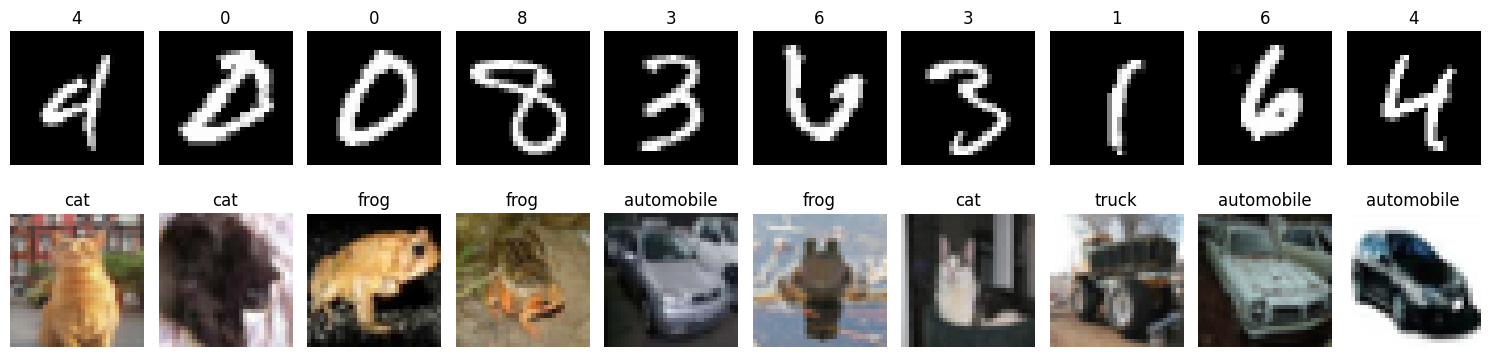

In [8]:
import matplotlib.pyplot as plt

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,4))

# MNIST row
for i in range(10):
    idx = np.random.randint(0, len(mnist_x_train))
    plt.subplot(2,10,i+1)
    plt.imshow(mnist_x_train[idx], cmap='gray')
    plt.title(mnist_y_train[idx])
    plt.axis('off')

# CIFAR row
for i in range(10):
    idx = np.random.randint(0, len(cifar_x_train))
    plt.subplot(2,10,10+i+1)
    plt.imshow(cifar_x_train[idx])
    plt.title(cifar_classes[int(cifar_y_train[idx])])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [11]:
# PROBLEM 3

import tensorflow as tf
import numpy as np

# load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

def preprocess(x, y):
    print("Before:")
    print("shape:", x.shape, "dtype:", x.dtype, "range:", x.min(), "-", x.max())
    print("label sample:", y[:5])

    # (a) normalize
    x = x.astype(np.float32) / 255.0
    print("\nAfter normalization:")
    print("dtype:", x.dtype, "range:", x.min(), "-", x.max())

    # (b) reshape
    if len(x.shape) == 3:
        x = x.reshape(-1, 28, 28, 1)
    print("\nAfter reshape:")
    print("shape:", x.shape)

    # (c) one-hot
    y = tf.keras.utils.to_categorical(y, 10)
    print("\nAfter one-hot:")
    print("shape:", y.shape)
    print("label sample:", y[:5])

    return x, y

x_train, y_train = preprocess(x_train, y_train)

Before:
shape: (60000, 28, 28) dtype: uint8 range: 0 - 255
label sample: [5 0 4 1 9]

After normalization:
dtype: float32 range: 0.0 - 1.0

After reshape:
shape: (60000, 28, 28, 1)

After one-hot:
shape: (60000, 10)
label sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


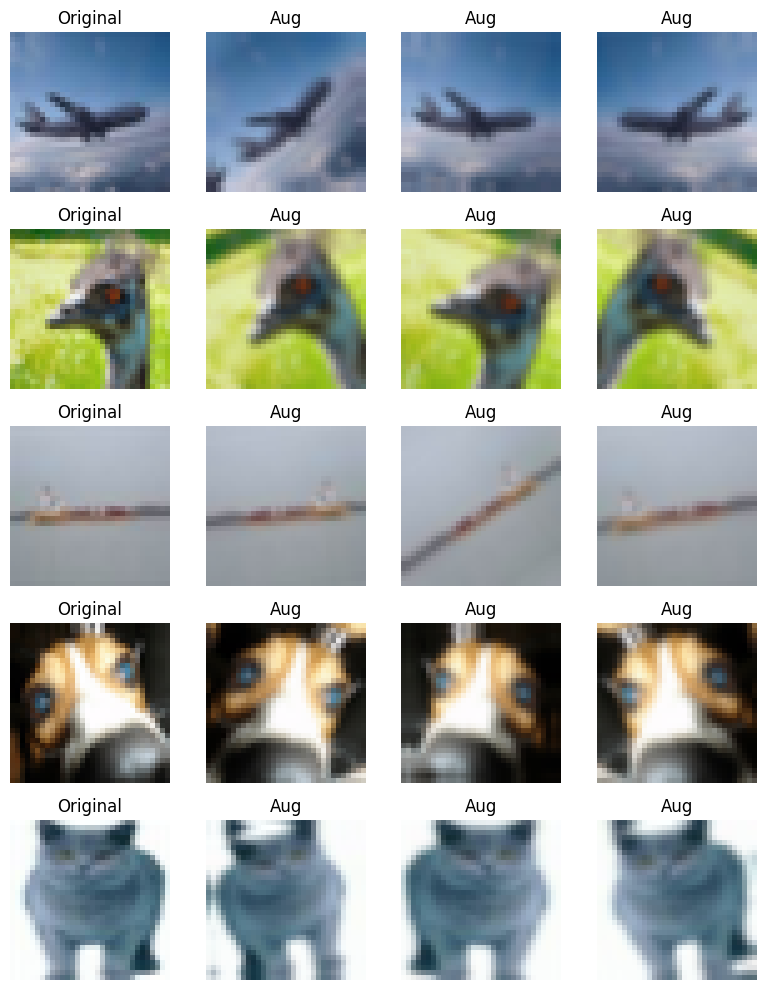

In [13]:
# PROBLEM 4

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

plt.figure(figsize=(8,10))

for i in range(5):
    idx = np.random.randint(0, len(x_train))
    img = x_train[idx]

    plt.subplot(5,4,i*4+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        aug_img = data_aug(tf.expand_dims(img, 0))[0].numpy().astype("uint8")
        plt.subplot(5,4,i*4+2+j)
        plt.imshow(aug_img)
        plt.title("Aug")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

## ANALYSIS & REFLECTION QUESTIONS (Task 1)

### Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?

**Answer:**

In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of feature channels in each image.

For a greyscale image, C = 1 because each pixel has only one intensity value.
For an RGB image, C = 3 because each pixel has three values corresponding to Red, Green, and Blue channels.

---

### Q2. What data loading strategies would you use for very large images (e.g., 1024×1024)?

**Answer:**

* Mini-batch loading: Load data in small batches instead of the entire dataset to reduce memory usage.
* Image resizing or patching: Resize images or split them into smaller patches (e.g., 256×256) to reduce computational cost.
* On-the-fly loading: Load images during training from disk instead of storing all in memory.

---

### Q3. What is wrong with normalising the test set using its own statistics?

**Answer:**

This causes data leakage because information from the test set is used during preprocessing.
It leads to overly optimistic evaluation results.

Correct approach: compute mean and standard deviation from the training set only and apply the same transformation to validation and test sets.


# **TASK 2**

In [17]:
# PROBLEM 1

import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    H, W = image.shape
    K = kernel.shape[0]

    # padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    H_p, W_p = image.shape

    out_h = (H_p - K) // stride + 1
    out_w = (W_p - K) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            region = image[i*stride:i*stride+K, j*stride:j*stride+K]
            output[i, j] = np.sum(region * kernel)

    return output


# test image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

result = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", result)
print("Output shape:", result.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


#PROBLEM 2

(a)

Formula:
Output = ⌊(Input − Kernel + 2P)/S⌋ + 1

= ⌊(28 − 5 + 0)/1⌋ + 1
= ⌊23⌋ + 1 = 24

Final size: 24 × 24

(b)

= ⌊(28 − 3 + 2×1)/1⌋ + 1
= ⌊(28 − 3 + 2)/1⌋ + 1
= ⌊27⌋ + 1 = 28

Final size: 28 × 28

(c)

= ⌊(32 − 3 + 0)/2⌋ + 1
= ⌊29/2⌋ + 1
= ⌊14.5⌋ + 1 = 14 + 1 = 15

Final size: 15 × 15

(d)

First layer:
= ⌊(32 − 3 + 2)/1⌋ + 1
= ⌊31⌋ + 1 = 32

→ output = 32 × 32

Second layer:
= ⌊(32 − 3 + 0)/1⌋ + 1
= ⌊29⌋ + 1 = 30

Final size: 30 × 30

In [18]:
# PROBLEM 3

import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2),

    tf.keras.layers.Conv2D(16, (5,5), activation='tanh', padding='valid'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='tanh'),
    tf.keras.layers.Dense(84, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

**Problem 4:**

Input (32x32x3)
→ Conv(32) → BN → ReLU → MaxPool
→ Conv(64) → BN → ReLU → MaxPool
→ Conv(128) → BN → ReLU → MaxPool
→ GlobalAveragePooling
→ Dense(128) → ReLU → Dropout(0.5)
→ Dense(10, Softmax)

The architecture uses three convolutional blocks with increasing filters (32 → 64 → 128) to progressively learn more complex features. Batch Normalisation stabilises training and ReLU introduces non-linearity. MaxPooling reduces spatial dimensions and computation. GlobalAveragePooling reduces parameters

In [19]:
# PROBLEM 4

import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

## ANALYSIS & REFLECTION QUESTIONS

### Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters.

**Answer:**

Assume input channels = C and output filters = F

* One 5×5 Conv layer:
  Params = (5×5×C)×F = 25CF

* Two 3×3 Conv layers:
  First layer = (3×3×C)×F = 9CF
  Second layer = (3×3×F)×F = 9F²

Total = 9CF + 9F²

If C ≈ F:
→ Total ≈ 18F² < 25F²

Therefore, two 3×3 layers use fewer parameters.

Advantages:

* More non-linearity
* Better feature extraction
* More efficient receptive field building

---

### Q2. What is the role of Batch Normalisation in a CNN? Where should it be placed?

**Answer:**

Batch Normalisation normalises the inputs of each layer to stabilise training.

Placement: Conv → BatchNorm → ReLU

Benefits:

* Faster convergence
* Allows higher learning rates
* Reduces internal covariate shift
* Provides slight regularisation

---

### Q3. What does GlobalAveragePooling do? What if replaced with Flatten?

**Answer:**

GlobalAveragePooling converts each feature map into a single value by averaging over spatial dimensions.

If replaced with Flatten:

* Parameter count increases significantly
* Higher risk of overfitting
* Keeps full spatial information

GlobalAveragePooling reduces parameters and improves generalisation.


# TASK **3**

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.7770 - loss: 0.8647 - val_accuracy: 0.9038 - val_loss: 0.3798
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.8907 - loss: 0.3892 - val_accuracy: 0.9223 - val_loss: 0.2799
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9087 - loss: 0.3164 - val_accuracy: 0.9333 - val_loss: 0.2345
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9207 - loss: 0.2724 - val_accuracy: 0.9428 - val_loss: 0.2037
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.9296 - loss: 0.2393 - val_accuracy: 0.9503 - val_loss: 0.1800
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9377 - loss: 0.2125 - val_accuracy: 0.9575 - val_loss: 0.1610
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.9441 - loss: 0.1901 - val_accuracy: 0.9618 - val_loss: 0.1451
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.9502 - loss: 0.1711 - 

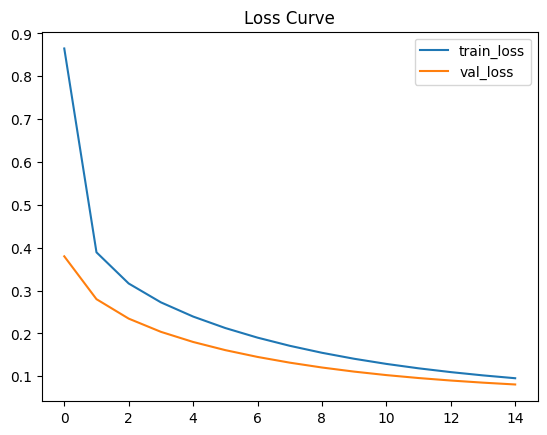

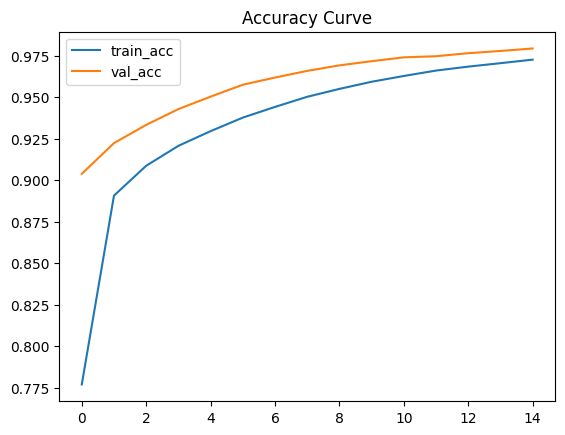

In [21]:
# PROBLEM 1

import tensorflow as tf
import matplotlib.pyplot as plt

# load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

# LeNet-5
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(16,(5,5),activation='tanh'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120,activation='tanh'),
    tf.keras.layers.Dense(84,activation='tanh'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1)

# loss plot
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.savefig("lenet_sgd_curves.png")

# accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("lenet_sgd_curves.png")

# test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

In [ ]:
# PROBLEM 2

import tensorflow as tf
import matplotlib.pyplot as plt

# load data
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# preprocess
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1,28,28,1)
y_train = tf.keras.utils.to_categorical(y_train,10)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),
        tf.keras.layers.Conv2D(16,(5,5),activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120,activation='tanh'),
        tf.keras.layers.Dense(84,activation='tanh'),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model

# SGD
model_sgd = build_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
hist_sgd = model_sgd.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# SGD + momentum
model_mom = build_model()
model_mom.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
hist_mom = model_mom.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# Adam
model_adam = build_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
hist_adam = model_adam.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# plot
plt.figure()
plt.plot(hist_sgd.history['val_accuracy'], label='SGD')
plt.plot(hist_mom.history['val_accuracy'], label='SGD+Momentum')
plt.plot(hist_adam.history['val_accuracy'], label='Adam')
plt.legend()
plt.title("Optimizer Comparison (Validation Accuracy)")
plt.savefig("optimiser_comparison.png")
plt.show()

In [ ]:
# PROBLEM 3

import tensorflow as tf
import numpy as np

# load data
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# preprocess
x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        model = build_model()  # fresh model

        model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        history = model.fit(x_train, y_train,
                            epochs=10,
                            batch_size=bs,
                            validation_split=0.1,
                            verbose=0)

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc
        print(f"LR={lr}, BS={bs} → Val Acc={val_acc:.4f}")

In [ ]:
# PROBLEM 4

import tensorflow as tf
import matplotlib.pyplot as plt

# load data
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# preprocess
x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def build_model(use_dropout=False, use_bn=False):
    model = tf.keras.Sequential()

    # block 1
    model.add(tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPooling2D())
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # block 2
    model.add(tf.keras.layers.Conv2D(64,(3,3),padding='same'))
    if use_bn:
        model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPooling2D())
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))

    # head
    model.add(tf.keras.layers.Flatten())
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.5))
    model.add(tf.keras.layers.Dense(10,activation='softmax'))

    return model


configs = {
    "No_Reg": (False, False),
    "Dropout": (True, False),
    "BatchNorm": (False, True),
    "Both": (True, True)
}

gaps = {}

for name, (d, b) in configs.items():
    model = build_model(use_dropout=d, use_bn=b)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=20,
                        batch_size=64,
                        validation_split=0.1,
                        verbose=0)

    # plot
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.legend()
    plt.title(name)
    plt.savefig(f"{name}.png")

    # gap
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gaps[name] = train_acc - val_acc

# print gaps
for k,v in gaps.items():
    print(k, "gap:", round(v,4))

In [ ]:
# PROBLEM 5

import tensorflow as tf
import matplotlib.pyplot as plt

# load data
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# preprocess
x_train = x_train.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(64,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model

# ---------- ReduceLROnPlateau ----------
model1 = build_model()
opt1 = tf.keras.optimizers.Adam(learning_rate=0.001)

model1.compile(optimizer=opt1, loss='categorical_crossentropy', metrics=['accuracy'])

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=0
)

lr_hist1 = []
class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr_hist1.append(self.model.optimizer.learning_rate.numpy())

hist1 = model1.fit(x_train, y_train,
                   epochs=30,
                   batch_size=64,
                   validation_split=0.1,
                   callbacks=[reduce_lr, LRLogger()],
                   verbose=0)

# ---------- Cosine Annealing ----------
model2 = build_model()

cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

opt2 = tf.keras.optimizers.Adam(learning_rate=cosine_lr)

model2.compile(optimizer=opt2, loss='categorical_crossentropy', metrics=['accuracy'])

lr_hist2 = []
class LRLogger2(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr_hist2.append(self.model.optimizer._decayed_lr(tf.float32).numpy())

hist2 = model2.fit(x_train, y_train,
                   epochs=30,
                   batch_size=64,
                   validation_split=0.1,
                   callbacks=[LRLogger2()],
                   verbose=0)

# ---------- Plot ----------
plt.figure(figsize=(10,4))

# LR plots
plt.subplot(1,2,1)
plt.plot(lr_hist1, label='ReduceLR')
plt.plot(lr_hist2, label='Cosine')
plt.title("LR vs Epoch")
plt.legend()

# Accuracy plots
plt.subplot(1,2,2)
plt.plot(hist1.history['val_accuracy'], label='ReduceLR')
plt.plot(hist2.history['val_accuracy'], label='Cosine')
plt.title("Val Accuracy vs Epoch")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

## ANALYSIS & REFLECTION QUESTIONS (Task 3)

### Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge. Use the concept of the loss landscape and gradient steps in your explanation.

**Answer:**

A very high learning rate causes the model to take excessively large steps in the loss landscape. Instead of moving toward the minimum, the updates overshoot the optimal point and jump across the valley. This leads to oscillations around the minimum or even divergence if the steps move the model to higher loss regions. As a result, the training loss does not decrease smoothly and may increase or fluctuate.

---

### Q2. Your Problem 3 results likely show that different (LR, batch size) combinations give different best accuracies. From your data: which combination worked best and which worked worst? Propose a hypothesis explaining the pattern you observed.

**Answer:**

Best combination: (write your best LR, batch size pair)
Worst combination: (write your worst LR, batch size pair)

Hypothesis: Moderate learning rates (e.g., 0.01 or 0.001) provide stable convergence, while very high learning rates (0.1) can cause instability. Smaller batch sizes introduce noise in gradient updates, which can help generalisation, whereas larger batch sizes provide smoother but sometimes less effective updates. The balance between learning rate and batch size determines convergence and performance.

---

### Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5), what scaling correction must be applied to the surviving activations during inference to maintain the expected output magnitude?

**Answer:**

Dropout is disabled during inference because it randomly drops neurons, which would make predictions inconsistent. At test time, the full network is used for stable and deterministic outputs.

For Dropout(0.5), the activations are scaled by a factor of 0.5 during training (or equivalently scaled at inference). This ensures that the expected output magnitude remains the same when all neurons are active.

---

### Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) what triggers the LR reduction, (ii) the shape of the LR curve, and (iii) which scenario each is better suited for.

**Answer:**

(i) Trigger:

* ReduceLROnPlateau reduces learning rate when validation loss stops improving.
* Cosine Annealing reduces learning rate based on a predefined schedule.

(ii) Shape:

* ReduceLROnPlateau gives step-wise drops in learning rate.
* Cosine Annealing gives a smooth cosine-shaped decay.

(iii) Usage:

* ReduceLROnPlateau is useful when training progress is uncertain and needs adaptive control.
* Cosine Annealing is useful when a smooth and gradual learning rate decay is preferred for better convergence.


# **TASK 4**

In [ ]:
# PROBLEM 1

import matplotlib.pyplot as plt
import numpy as np

# get first conv layer weights
filters = model.layers[0].get_weights()[0]   # shape (K, K, C_in, C_out)

num_filters = filters.shape[-1]

plt.figure(figsize=(10,10))

for i in range(num_filters):
    f = filters[:,:,:,i]

    # convert to single channel (mean over RGB)
    f = np.mean(f, axis=-1)

    # normalize to [0,1]
    f = (f - f.min()) / (f.max() - f.min() + 1e-5)

    plt.subplot(int(np.sqrt(num_filters))+1, int(np.sqrt(num_filters))+1, i+1)
    plt.imshow(f, cmap='gray')
    plt.title(f"{i}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

In [ ]:
# PROBLEM 2

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0

# pick one image
img = x_test[0]
img_input = np.expand_dims(img, axis=0)

# get conv layers
conv_layers = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

# sub-model
feature_model = tf.keras.Model(inputs=model.input, outputs=conv_layers)

# get feature maps
feature_maps = feature_model.predict(img_input)

# -------- First conv layer --------
fmaps1 = feature_maps[0][0]

plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(fmaps1[:,:,i], cmap='gray')
    plt.axis('off')

plt.savefig("fmaps_layer1.png")
plt.show()

# -------- Last conv layer --------
fmaps_last = feature_maps[-1][0]

plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(fmaps_last[:,:,i], cmap='gray')
    plt.axis('off')

plt.savefig("fmaps_last.png")
plt.show()

In [ ]:
# PROBLEM 3

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# last conv layer name (change if needed)
last_conv_layer = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)][-1]

grad_model = tf.keras.models.Model(
    [model.inputs], [last_conv_layer.output, model.output]
)

def grad_cam(image, class_index):
    img = np.expand_dims(image, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, (32,32))

    return heatmap

def overlay(image, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = heatmap * 0.4 + image
    return np.uint8(superimposed)

# load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

plt.figure(figsize=(10,10))

count = 1
correct = 0
wrong_done = False

for i in range(len(x_test)):
    img = x_test[i]
    true_label = int(y_test[i])

    pred = model.predict(np.expand_dims(img,0), verbose=0)
    pred_label = np.argmax(pred)

    # 3 correct
    if pred_label == true_label and correct < 3:
        heat = grad_cam(img, pred_label)
        out = overlay((img*255).astype("uint8"), heat)

        plt.subplot(4,2,count)
        plt.imshow(out)
        plt.title("Correct")
        plt.axis('off')
        count += 1
        correct += 1

    # 1 wrong
    if pred_label != true_label and not wrong_done:
        # predicted class heatmap
        heat_pred = grad_cam(img, pred_label)
        out_pred = overlay((img*255).astype("uint8"), heat_pred)

        # true class heatmap
        heat_true = grad_cam(img, true_label)
        out_true = overlay((img*255).astype("uint8"), heat_true)

        plt.subplot(4,2,count)
        plt.imshow(out_pred)
        plt.title("Wrong-Pred")
        plt.axis('off')
        count += 1

        plt.subplot(4,2,count)
        plt.imshow(out_true)
        plt.title("Wrong-True")
        plt.axis('off')
        count += 1

        wrong_done = True

    if correct == 3 and wrong_done:
        break

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

In [ ]:
# PROBLEM 4

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# CIFAR-10 class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# load data
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

# predictions
y_pred = model.predict(x_test, verbose=0)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

# confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# classification report
print(classification_report(y_true, y_pred_labels, target_names=classes))

# most confused pair
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most confused pair:", classes[i], "→", classes[j])

# show 5 misclassified examples
count = 0
plt.figure(figsize=(10,5))

for idx in range(len(x_test)):
    if y_true[idx] == i and y_pred_labels[idx] == j:
        plt.subplot(1,5,count+1)
        plt.imshow(x_test[idx])
        plt.title(f"T:{classes[i]}\nP:{classes[j]}")
        plt.axis('off')
        count += 1
        if count == 5:
            break

plt.show()

## ANALYSIS & REFLECTION QUESTIONS (Task 4)

### Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region. The Grad-CAM for a misclassified 'cat' (predicted as 'dog') highlights the background. What does this tell you about what the model has learned? Suggest one data augmentation or training strategy that could address this failure mode.

**Answer:**

This indicates that the model has learned to rely on spurious background features rather than the actual object. For correct predictions, it focuses on meaningful regions (like the cat’s face), but for incorrect ones, it attends to irrelevant background patterns.

A suitable strategy is **data augmentation such as random cropping or background randomisation**, which forces the model to focus on the object itself rather than background cues.

---

### Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused with each other (e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained on pixel features might struggle to distinguish these pairs. What architectural change or additional input modality might help?

**Answer:**

These classes share very similar visual features (shape, texture, colour), making it difficult for CNNs relying only on pixel-level patterns to distinguish them. For example, cats and dogs have similar edges and textures, and automobiles and trucks have similar structures.

An architectural improvement could be using **deeper networks or attention mechanisms** to capture finer details. Additionally, incorporating **contextual or multi-modal inputs (e.g., metadata or higher-resolution images)** can improve discrimination.

---

### Q3. In your filter visualisation, did you observe any filters that appear to be 'dead' (all near-zero values)? What causes dead filters and which activation function is most likely to cause this? Name one remedy.

**Answer:**

Yes, some filters may appear nearly zero, indicating they are not contributing to feature extraction. These are called dead filters.

They are often caused by the **ReLU activation function**, where neurons can become permanently inactive if they receive negative inputs.

A remedy is to use **Leaky ReLU or ELU**, which allows small gradients even for negative inputs and prevents neurons from dying.
